In [3]:
import cv2
import os

def capture_student_images():
    # Input student details
    student_id = input("Enter student ID: ")
    full_name = input("Enter full name: ")

    # Create a directory to save images
    dataset_path = "dataset"
    user_folder = os.path.join(dataset_path, f"{student_id}_{full_name.replace(' ', '_')}")

    if not os.path.exists(user_folder):
        os.makedirs(user_folder)

    # Load the Haar Cascade classifier for face detection
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

    # Initialize the webcam
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Error: Could not open webcam.")
        return

    count = 0
    max_images = 500  # Number of images to capture

    print("Capturing images... Press 'q' to quit.")

    while count < max_images:
        # Capture frame-by-frame
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame.")
            break

        # Convert to grayscale
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Detect faces
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

        # Draw rectangle around detected faces and save the images
        for (x, y, w, h) in faces:
            cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)
            face = gray[y:y + h, x:x + w]
            face = cv2.resize(face, (128, 128))  # Resize to 128x128
            # Save the image with both student ID and name in the filename
            filename = f"{student_id}_{full_name.replace(' ', '_')}_{count}.jpg"
            cv2.imwrite(os.path.join(user_folder, filename), face)
            count += 1

        # Overlay count text on the camera feed
        cv2.putText(frame, f"Images Captured: {count}/{max_images}", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

        # Display the resulting frame
        cv2.imshow('Frame', frame)

        # Break the loop if 'q' is pressed
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    # Release the webcam and close windows
    cap.release()
    cv2.destroyAllWindows()

    if count > 0:
        print(f"Captured {count} images for Student ID {student_id}, Name {full_name}.")
    else:
        print("No images captured.")

# Run the function
capture_student_images()


Enter student ID:  211811
Enter full name:  Sishir Dangi


Capturing images... Press 'q' to quit.
Captured 500 images for Student ID 211811, Name Sishir Dangi.


In [ ]:
# Data loading and encoding

In [1]:
import os
import numpy as np
import cv2
import pickle
from tensorflow.keras.utils import to_categorical

def load_data(dataset_path, img_size=(64, 64)):
    """
    Loads and processes the dataset from the given directory.

    Args:
        dataset_path (str): Path to the dataset directory.
        img_size (tuple): Target size for resizing images (width, height).

    Returns:
        tuple: (images, labels, label_map)
            - images: Numpy array of processed images.
            - labels: Numpy array of corresponding one-hot encoded labels.
            - label_map: Dictionary mapping user IDs to class indices.
    """
    images = []
    labels = []
    label_map = {}  # Map user ID to class index
    class_index = 0

    # Traverse through each user folder
    for user_folder in os.listdir(dataset_path):
        user_folder_path = os.path.join(dataset_path, user_folder)
        if os.path.isdir(user_folder_path):  # Ensure it's a directory
            # Add user ID to label map if not already present
            if user_folder not in label_map:
                label_map[user_folder] = class_index
                class_index += 1

            # Traverse through images in the user's folder
            for image_name in os.listdir(user_folder_path):
                image_path = os.path.join(user_folder_path, image_name)
                try:
                    image = cv2.imread(image_path)
                    if image is not None:  # Ensure image is read successfully
                        image = cv2.resize(image, img_size)  # Resize to target dimensions
                        images.append(image)
                        labels.append(label_map[user_folder])  # Use class index
                    else:
                        print(f"Warning: Unable to read {image_path}. Skipping...")
                except Exception as e:
                    print(f"Error processing {image_path}: {e}. Skipping...")

    # Convert lists to numpy arrays
    images = np.array(images, dtype="float32")
    labels = np.array(labels)

    return images, labels, label_map

# Load the data
dataset_path = "dataset"  # Change to your actual dataset path
X, y, label_map = load_data(dataset_path, img_size=(64, 64))

# Check if dataset is empty
if len(X) == 0 or len(y) == 0:
    print("Dataset is empty or not loaded correctly. Check the dataset path and contents.")
else:
    # Normalize the images
    X /= 255.0  # Normalize pixel values to [0, 1]

    # One-hot encode labels
    y = to_categorical(y, num_classes=len(label_map))

    # Display the label map for reference
    print("Label Map (User ID to Class Index):")
    for user_id, class_idx in label_map.items():
        print(f"{user_id}: {class_idx}")

    # Display dataset shape
    print(f"Dataset loaded successfully:")
    print(f"  - Number of images: {X.shape[0]}")
    print(f"  - Image dimensions: {X.shape[1:]} (Height x Width x Channels)")
    print(f"  - Number of classes: {len(label_map)}")

    # Save the label map to a .pkl file in the 'models' folder
    models_dir = "models"
    os.makedirs(models_dir, exist_ok=True)
    label_map_path = os.path.join(models_dir, "label_map.pkl")
    
    with open(label_map_path, "wb") as f:
        pickle.dump(label_map, f)
    print(f"Label map saved to: {label_map_path}")


Label Map (User ID to Class Index):
211811_Sishir_Dangi: 0
211842_Roshan_Sah: 1
Dataset loaded successfully:
  - Number of images: 1001
  - Image dimensions: (64, 64, 3) (Height x Width x Channels)
  - Number of classes: 2
Label map saved to: models\label_map.pkl


In [16]:
# Train CNN model 

In [2]:
import os
import numpy as np
import cv2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Load dataset
def load_data(dataset_path):
    images = []
    labels = []
    label_map = {}
    class_index = 0

    for user_id in os.listdir(dataset_path):
        user_folder = os.path.join(dataset_path, user_id)
        if os.path.isdir(user_folder):
            if user_id not in label_map:
                label_map[user_id] = class_index
                class_index += 1
            for image_name in os.listdir(user_folder):
                image_path = os.path.join(user_folder, image_name)
                image = cv2.imread(image_path)
                if image is not None:
                    image = cv2.resize(image, (64, 64))
                    images.append(image)
                    labels.append(label_map[user_id])

    return np.array(images), np.array(labels), label_map

# Load data
dataset_path = "dataset"
X, y, label_map = load_data(dataset_path)

if X.size == 0 or y.size == 0:
    raise ValueError("Dataset is empty. Check the dataset directory and contents.")

X = X.astype('float32') / 255.0
y = to_categorical(y)

print(f"Dataset X shape: {X.shape}")
print(f"Labels y shape: {y.shape}")
print(f"Label Map: {label_map}")

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# CNN model
def create_cnn_model(input_shape, num_classes):
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))
    return model

input_shape = (64, 64, 3)
num_classes = y.shape[1]
model = create_cnn_model(input_shape, num_classes)
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

# Ensure 'models' folder exists
model_dir = "models"
os.makedirs(model_dir, exist_ok=True)

# Save the trained model as FacedataModel.h5 in 'models' folder
model_path = os.path.join(model_dir, "FacedataModel.h5")
model.save(model_path)
print(f"Model saved to '{model_path}'")

# Print final metrics
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])


Dataset X shape: (1001, 64, 64, 3)
Labels y shape: (1001, 2)
Label Map: {'211811_Sishir_Dangi': 0, '211842_Roshan_Sah': 1}


c:\Users\shish\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 215ms/step - accuracy: 0.9736 - loss: 0.0980 - val_accuracy: 0.9552 - val_loss: 0.4949
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 194ms/step - accuracy: 0.9981 - loss: 0.0060 - val_accuracy: 0.4826 - val_loss: 2.0952
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step - accuracy: 1.0000 - loss: 3.2328e-05 - val_accuracy: 0.4826 - val_loss: 3.7903
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 205ms/step - accuracy: 0.9999 - loss: 5.4347e-04 - val_accuracy: 0.4826 - val_loss: 5.0222
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 209ms/step - accuracy: 0.9983 - loss: 0.0344 - val_accuracy: 0.4826 - val_loss: 7.4423
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 197ms/step - accuracy: 1.0000 - loss: 5.1474e-04 - val_accuracy: 0.4826 - val_loss: 9.8122
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 222ms/step - accuracy: 1.0000 - loss: 1.8088e-07 - val_accuracy: 0.4826 - val_loss: 12.2124
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - accuracy: 1.0000 - loss: 0.0000

Model saved to 'models\FacedataModel.h5'
Final Training Accuracy: 1.0
Final Validation Accuracy: 0.9950248599052429


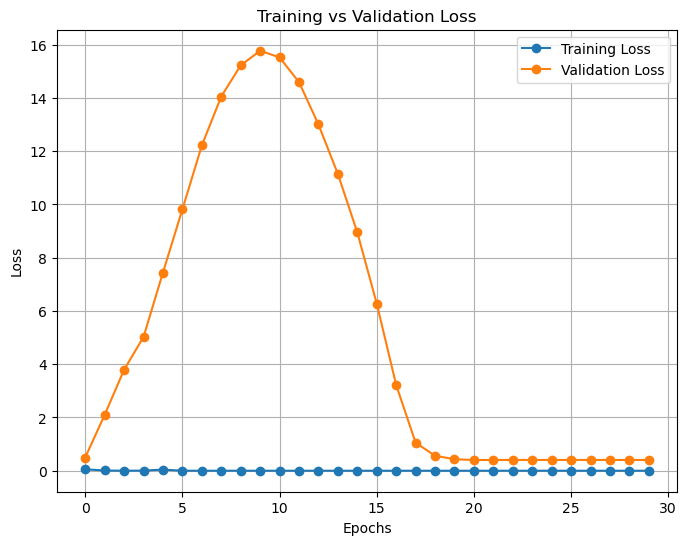

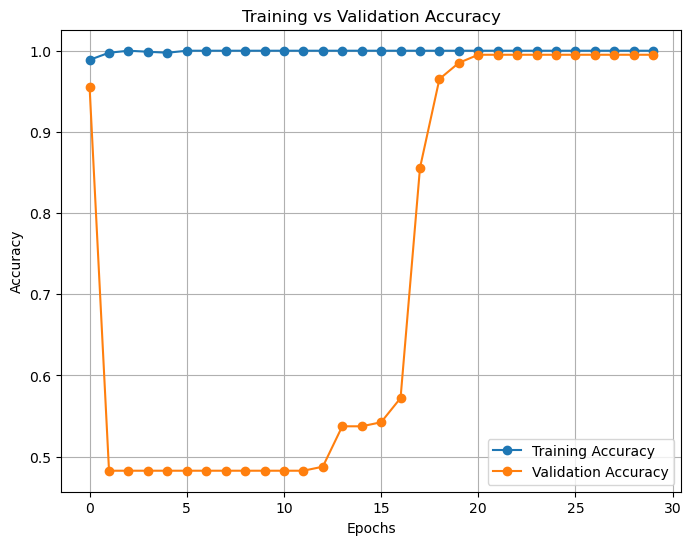

In [3]:
import matplotlib.pyplot as plt

# Ensure the history object has the required data
if 'loss' in history.history and 'val_loss' in history.history:
    # Plot training and validation loss
    plt.figure(figsize=(8, 6))
    plt.plot(history.history['loss'], label='Training Loss', marker='o')
    plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
    plt.legend()
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid()
    plt.show()

if 'accuracy' in history.history and 'val_accuracy' in history.history:
    # Plot training and validation accuracy
    plt.figure(figsize=(8, 6))
    plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
    plt.legend()
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.grid()
    plt.show()


In [19]:
# code for face recognition 

In [4]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import pickle
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

# Load the trained model
try:
    model = load_model("models/FacedataModel.h5")
except Exception as e:
    print(f"Error loading model: {e}")
    exit()

# Compile the model to avoid warnings
model.compile(optimizer=Adam(), loss=CategoricalCrossentropy(), metrics=['accuracy'])

# Load the label map
try:
    with open('models/label_map.pkl', 'rb') as f:
        label_map = pickle.load(f)
except FileNotFoundError:
    print("Error: label_map.pkl file not found!")
    exit()

# Reverse the label map for easy lookup
reverse_label_map = {v: k for k, v in label_map.items()}

# Set a stricter confidence threshold
UNKNOWN_THRESHOLD = 0.8

# Load Haar Cascade for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
if face_cascade.empty():
    print("Error loading Haar Cascade!")
    exit()

# Open the webcam
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

print("Starting real-time face recognition. Press 'q' to quit.")

while True:
    # Capture frame-by-frame
    ret, frame = cap.read()
    if not ret:
        print("Failed to capture frame. Exiting...")
        break

    # Convert the frame to grayscale for face detection
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect faces in the frame
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(64, 64))

    for (x, y, w, h) in faces:
        # Extract and preprocess the face region
        face_gray = gray[y:y + h, x:x + w]
        try:
            face_resized = cv2.resize(face_gray, (64, 64))  # Resize to 64x64
            face_normalized = face_resized.astype("float32") / 255.0  # Normalize to [0, 1]
            face_rgb = np.stack([face_normalized] * 3, axis=-1)  # Convert to 3-channel RGB
            face_reshaped = np.expand_dims(face_rgb, axis=0)  # Add batch dimension

            # Predict the class
            predictions = model.predict(face_reshaped, verbose=0)
            class_index = np.argmax(predictions)  # Index of the highest confidence
            confidence = np.max(predictions)  # Highest confidence level

            # Debugging information
            print(f"Predictions: {predictions}")
            print(f"Predicted class index: {class_index}, Confidence: {confidence:.2f}")

            # Determine the label
            if confidence < UNKNOWN_THRESHOLD:  # Stricter threshold for "Unknown"
                user_id = "Unknown"
            else:
                user_id = reverse_label_map.get(class_index, "Unknown")  # Default to "Unknown" if index not in map

            # Display the result on the frame
            label = f"{user_id} ({confidence:.2f})"
            cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)  # Draw rectangle around the face
            cv2.putText(frame, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)  # Display the label

        except Exception as e:
            print(f"Error processing face: {e}")

    # Show the resulting frame
    cv2.imshow("Face Recognition", frame)

    # Break the loop if 'q' is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the webcam and close OpenCV windows
cap.release()
cv2.destroyAllWindows()
print("Real-time face recognition ended.")


Starting real-time face recognition. Press 'q' to quit.
Predictions: [[1.7536204e-10 1.0000000e+00]]
Predicted class index: 1, Confidence: 1.00
Predictions: [[7.631351e-30 1.000000e+00]]
Predicted class index: 1, Confidence: 1.00
Predictions: [[1.15029844e-32 1.00000000e+00]]
Predicted class index: 1, Confidence: 1.00
Predictions: [[1.447829e-35 1.000000e+00]]
Predicted class index: 1, Confidence: 1.00
Predictions: [[1.1578861e-36 1.0000000e+00]]
Predicted class index: 1, Confidence: 1.00
Predictions: [[2.690514e-35 1.000000e+00]]
Predicted class index: 1, Confidence: 1.00
Predictions: [[0. 1.]]
Predicted class index: 1, Confidence: 1.00
Predictions: [[0. 1.]]
Predicted class index: 1, Confidence: 1.00
Predictions: [[0. 1.]]
Predicted class index: 1, Confidence: 1.00
Predictions: [[1.3214138e-37 1.0000000e+00]]
Predicted class index: 1, Confidence: 1.00
Predictions: [[4.5145033e-35 1.0000000e+00]]
Predicted class index: 1, Confidence: 1.00
Predictions: [[5.7935037e-37 1.0000000e+00]]
P